In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Set seaborn style for better aesthetics
sns.set(style="whitegrid")

# Load the Product Monthly Panel dataset
file_path = 'product_monthly_panel.csv'
product_df = pd.read_csv(file_path)

# Convert 'submission_time' to datetime
product_df['submission_time'] = pd.to_datetime(product_df['submission_time'])

# Display the first five rows of the dataset
print("First five rows of the Product Monthly Panel dataset:")
print(product_df.head())

First five rows of the Product Monthly Panel dataset:
  product_id submission_time  rating  is_recommended  helpfulness  \
0    P107306      2008-09-30     4.0             NaN     0.883333   
1    P107306      2008-10-31     4.5             NaN     0.833333   
2    P107306      2008-11-30     1.0             NaN     0.833333   
3    P107306      2008-12-31     4.5             NaN     0.750000   
4    P107306      2009-01-31     5.0             NaN     0.833333   

   total_feedback_count  total_neg_feedback_count  total_pos_feedback_count  \
0                    15                         2                        13   
1                     6                         1                         5   
2                     6                         1                         5   
3                     6                         1                         5   
4                     8                         2                         6   

   price_usd brand_name  skin_tone eye_color    skin_typ

In [2]:
# 1. Inspecting Data Types and Missing Values

# Display data types of each column
print("\nData Types of Each Column:")
print(product_df.dtypes)

# Check for missing values
print("\nMissing Values in Each Column:")
print(product_df.isnull().sum())


Data Types of Each Column:
product_id                          object
submission_time             datetime64[ns]
rating                             float64
is_recommended                     float64
helpfulness                        float64
total_feedback_count                 int64
total_neg_feedback_count             int64
total_pos_feedback_count             int64
price_usd                          float64
brand_name                          object
skin_tone                           object
eye_color                           object
skin_type                           object
hair_color                          object
dtype: object

Missing Values in Each Column:
product_id                      0
submission_time                 0
rating                          0
is_recommended              16168
helpfulness                  3801
total_feedback_count            0
total_neg_feedback_count        0
total_pos_feedback_count        0
price_usd                       0
brand_name        

In [3]:
# 2. Calculating Summary Statistics
# Select numerical columns
numerical_cols = product_df.select_dtypes(include=[np.number]).columns
print("\nNumerical Columns:")
print(numerical_cols)


Numerical Columns:
Index(['rating', 'is_recommended', 'helpfulness', 'total_feedback_count',
       'total_neg_feedback_count', 'total_pos_feedback_count', 'price_usd'],
      dtype='object')


In [4]:
# Calculate the mean of numerical columns
mean_values = product_df[numerical_cols].mean()
print("\nMean Values:")
print(mean_values)


Mean Values:
rating                       4.080463
is_recommended               0.749800
helpfulness                  0.782185
total_feedback_count        62.390722
total_neg_feedback_count    13.366020
total_pos_feedback_count    49.024702
price_usd                   52.180863
dtype: float64


In [5]:
# Calculate the median of numerical columns
median_values = product_df[numerical_cols].median()
print("\nMedian Values:")
print(median_values)


Median Values:
rating                       4.315789
is_recommended               0.846154
helpfulness                  0.817002
total_feedback_count        19.000000
total_neg_feedback_count     3.000000
total_pos_feedback_count    14.000000
price_usd                   40.000000
dtype: float64


In [6]:
# Calculate the mode of numerical columns
mode_values = product_df[numerical_cols].mode().iloc[0]
print("\nMode Values:")
print(mode_values)


Mode Values:
rating                       5.0
is_recommended               1.0
helpfulness                  1.0
total_feedback_count         0.0
total_neg_feedback_count     0.0
total_pos_feedback_count     0.0
price_usd                   38.0
Name: 0, dtype: float64


In [7]:
# Calculate the standard deviation of numerical columns
std_dev = product_df[numerical_cols].std()
print("\nStandard Deviation:")
print(std_dev)


Standard Deviation:
rating                        0.946480
is_recommended                0.302671
helpfulness                   0.198049
total_feedback_count        180.059654
total_neg_feedback_count     40.991508
total_pos_feedback_count    146.330668
price_usd                    48.140691
dtype: float64


In [8]:
# Calculate the range for numerical columns
range_values = product_df[numerical_cols].max() - product_df[numerical_cols].min()
print("\nRange of Values:")
print(range_values)


Range of Values:
rating                          4.0
is_recommended                  1.0
helpfulness                     1.0
total_feedback_count        11975.0
total_neg_feedback_count     2155.0
total_pos_feedback_count     9820.0
price_usd                    1897.0
dtype: float64


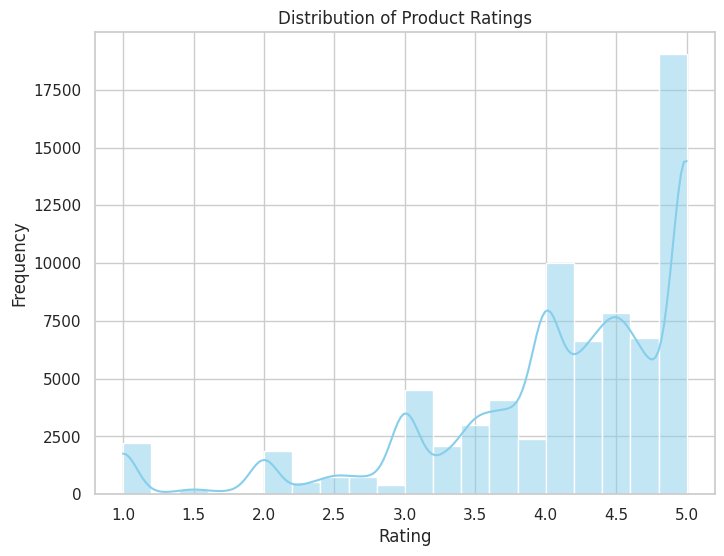

In [9]:
# 3. Data Visualization

# 3.1 Histogram of Product Ratings
plt.figure(figsize=(8,6))
sns.histplot(product_df['rating'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

<ipython-input-10-bad818838ae4>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='brand_name', y='price_usd', data=product_df[product_df['brand_name'].isin(top_brands)], palette='Set2')


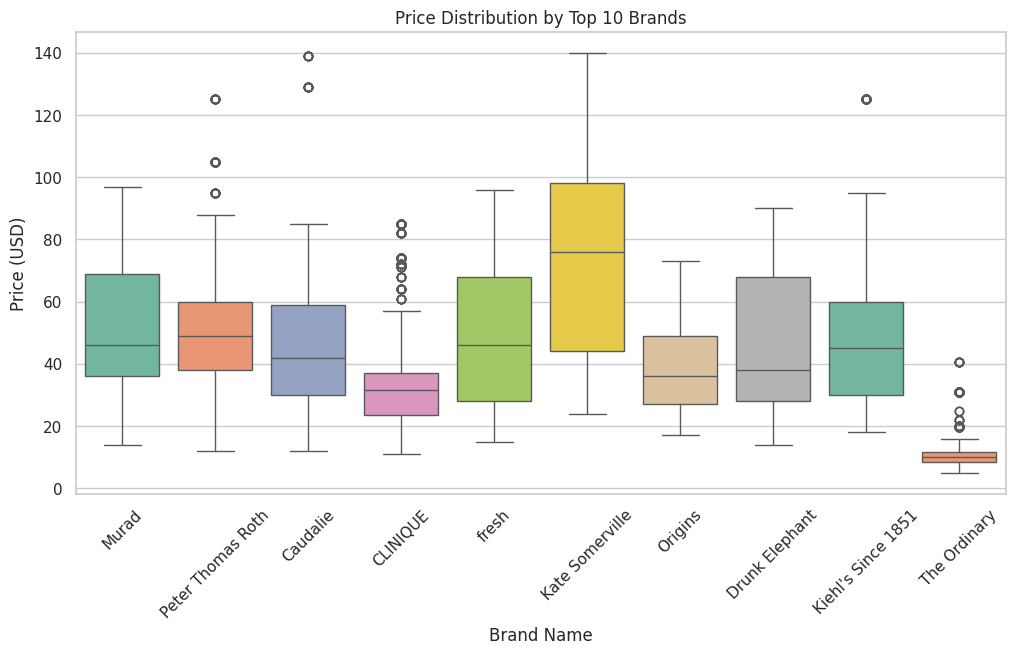

In [10]:
# 3.2 Box Plot of Price by Brand (Top 10 Brands)
top_brands = product_df['brand_name'].value_counts().nlargest(10).index
plt.figure(figsize=(12,6))
sns.boxplot(x='brand_name', y='price_usd', data=product_df[product_df['brand_name'].isin(top_brands)], palette='Set2')
plt.title('Price Distribution by Top 10 Brands')
plt.xlabel('Brand Name')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)
plt.show()

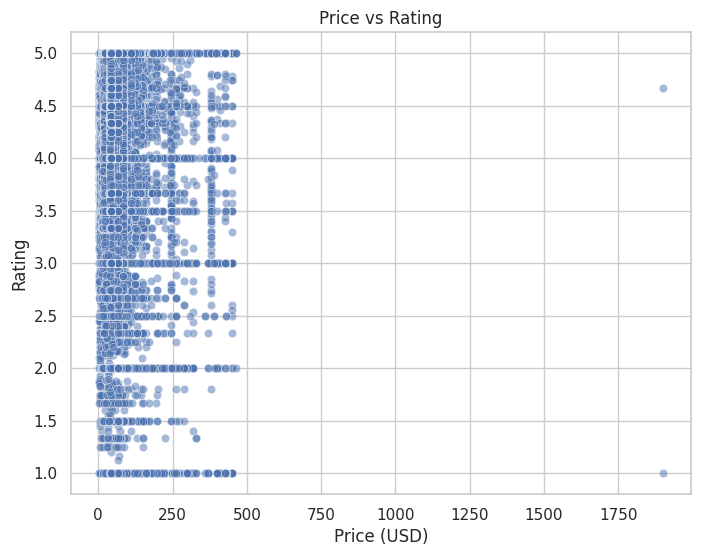

In [11]:
# 3.3 Scatter Plot of Price vs Rating
plt.figure(figsize=(8,6))
sns.scatterplot(x='price_usd', y='rating', data=product_df, alpha=0.5)
plt.title('Price vs Rating')
plt.xlabel('Price (USD)')
plt.ylabel('Rating')
plt.show()

<ipython-input-12-e587f1d5d740>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='skin_type', y='rating', data=product_df, ci=None, palette='pastel')
<ipython-input-12-e587f1d5d740>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='skin_type', y='rating', data=product_df, ci=None, palette='pastel')


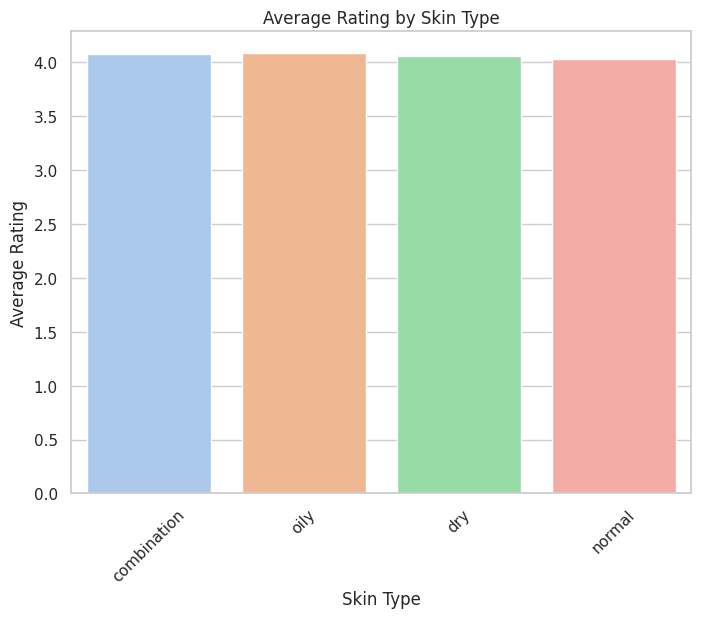

In [12]:
# 3.4 Bar Chart of Average Rating by Skin Type
plt.figure(figsize=(8,6))
sns.barplot(x='skin_type', y='rating', data=product_df, ci=None, palette='pastel')
plt.title('Average Rating by Skin Type')
plt.xlabel('Skin Type')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

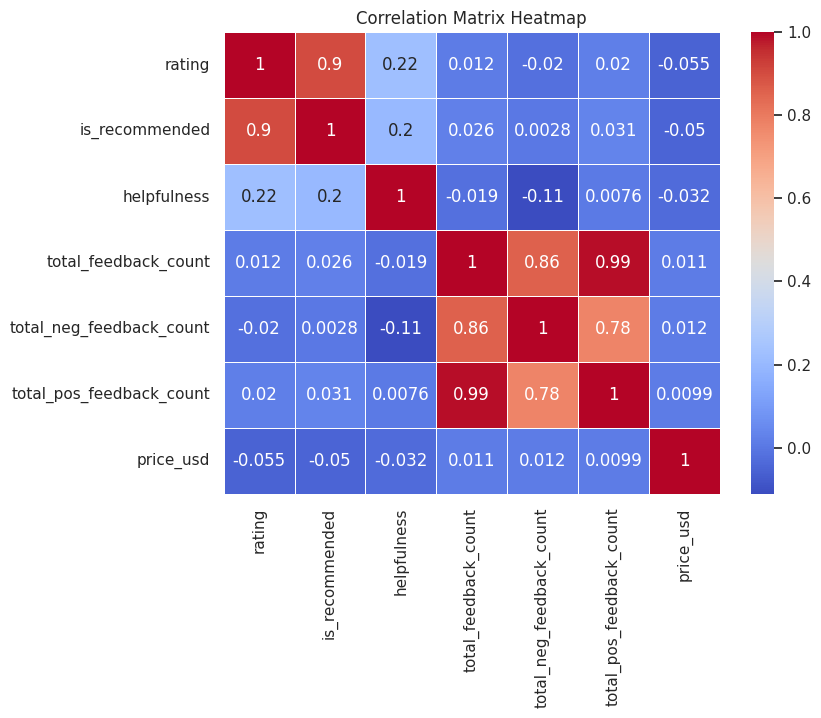

In [13]:
# 3.5 Heatmap of Correlation Matrix
corr_matrix = product_df[numerical_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [14]:
# 4. Handling Categorical Data Separately

# Select categorical columns
categorical_cols = product_df.select_dtypes(include=['category', 'object']).columns
print("\nCategorical Columns:")
print(categorical_cols)


Categorical Columns:
Index(['product_id', 'brand_name', 'skin_tone', 'eye_color', 'skin_type',
       'hair_color'],
      dtype='object')


In [15]:
# Frequency count for categorical columns
print("\nFrequency Counts for Categorical Columns:")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(product_df[col].value_counts().head(10))


Frequency Counts for Categorical Columns:

Column: product_id
product_id
P94421     176
P481817    176
P7880      176
P173726    175
P471788    175
P4016      175
P4010      175
P12573     175
P42204     175
P453816    174
Name: count, dtype: int64

Column: brand_name
brand_name
CLINIQUE              5864
Murad                 3249
Peter Thomas Roth     3092
fresh                 2244
Origins               2064
Kate Somerville       2036
The Ordinary          1799
Drunk Elephant        1755
Kiehl's Since 1851    1751
Caudalie              1704
Name: count, dtype: int64

Column: skin_tone
skin_tone
light          17504
fair           14056
lightMedium    12286
mediumTan       4092
medium          3973
fairLight       3733
tan             2243
deep            1231
rich             340
porcelain        109
Name: count, dtype: int64

Column: eye_color
eye_color
brown    29415
blue     11155
green     7729
hazel     7490
Grey       498
gray        62
Name: count, dtype: int64

Column: skin

<ipython-input-16-7a21e0ee1190>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='skin_tone', data=product_df, order=product_df['skin_tone'].value_counts().index, palette='Set3')


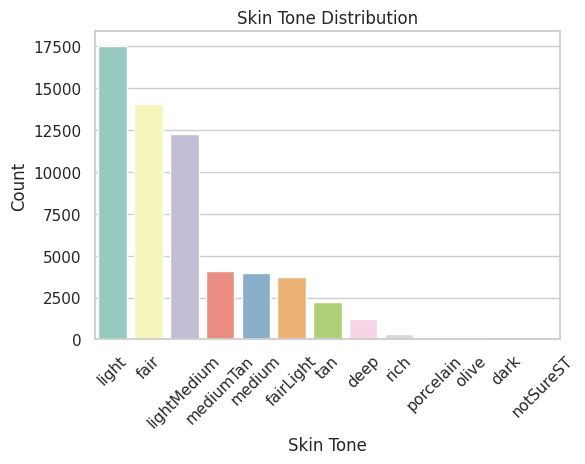

In [16]:
# Bar chart of Skin Tone Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='skin_tone', data=product_df, order=product_df['skin_tone'].value_counts().index, palette='Set3')
plt.title('Skin Tone Distribution')
plt.xlabel('Skin Tone')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


<ipython-input-17-a85f2df0f13b>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='eye_color', data=product_df, order=product_df['eye_color'].value_counts().index, palette='Set1')


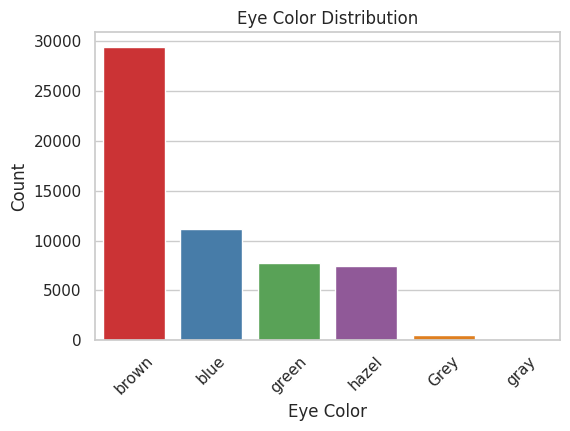

In [17]:
# Bar chart of Eye Color Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='eye_color', data=product_df, order=product_df['eye_color'].value_counts().index, palette='Set1')
plt.title('Eye Color Distribution')
plt.xlabel('Eye Color')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


In [18]:
# 5. Additional Insights

# Correlation Heatmap Interpretation
print("\nCorrelation Matrix:")
print(corr_matrix)




Correlation Matrix:
                            rating  is_recommended  helpfulness  \
rating                    1.000000        0.900592     0.222839   
is_recommended            0.900592        1.000000     0.201676   
helpfulness               0.222839        0.201676     1.000000   
total_feedback_count      0.011806        0.025987    -0.019466   
total_neg_feedback_count -0.019945        0.002769    -0.112543   
total_pos_feedback_count  0.020115        0.031304     0.007584   
price_usd                -0.054682       -0.049903    -0.032455   

                          total_feedback_count  total_neg_feedback_count  \
rating                                0.011806                 -0.019945   
is_recommended                        0.025987                  0.002769   
helpfulness                          -0.019466                 -0.112543   
total_feedback_count                  1.000000                  0.859590   
total_neg_feedback_count              0.859590                